In [ ]:
%pip install -qq -U ultralytics lap>=0.5.12

VIDEO FILE
1. Rename "\<your-video-name\>.mp4" to your video filename
2. The video should be 10-15 sec and less than 720p resolution
3. It should be video of only one person performing any activities
4. To ensure proper .mp4 format, please use the below script:  
ffmpeg -i full.mp4 \\   
-c:v libx264 -pix_fmt yuv420p \\   
-c:a aac \\  
-movflags +faststart \\  
\<your-video-name\>.mp4

In [ ]:
video_file="<your-video-name>.mp4"

BBs DETECTION : YOLO, TRACKING OBJECTS: BoT-SORT

In [ ]:
import cv2
import os
import torch
from ultralytics import YOLO


def get_device():
    if torch.cuda.is_available():
        return "cuda"
    else:
        return "cpu"

def run_yolo_botsort(video_file, output_frame_dir="frames_out"):
    os.makedirs(output_frame_dir, exist_ok=True)

    model = YOLO("yolo26m.pt")
    device = get_device()
    model.to(device)

    cap = cv2.VideoCapture(video_file)
    frame_id = 0

    all_frames_data = []

    track_to_object = {}
    next_object_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model.track(
            source=frame,
            persist=True,
            tracker="botsort.yaml",
            classes=[0],
            device=device,
            verbose=False
        )

        r = results[0]
        boxes = r.boxes

        frame_data = []

        if boxes is not None and boxes.id is not None:
            track_ids = boxes.id.cpu().numpy()
            xyxy = boxes.xyxy.cpu().numpy()
            confs = boxes.conf.cpu().numpy()
            clss = boxes.cls.cpu().numpy()

            for i in range(len(track_ids)):
                track_id = int(track_ids[i])

                x1, y1, x2, y2 = xyxy[i]
                conf = float(confs[i])
                cls = int(clss[i])
                class_name = model.names[cls]

                # object_id mapping (your semantic layer)
                if track_id not in track_to_object:
                    track_to_object[track_id] = next_object_id
                    next_object_id += 1

                object_id = track_to_object[track_id]

                frame_data.append({
                    "frame_id": frame_id,
                    "track_id": track_id,
                    "object_id": object_id,
                    "class": class_name,
                    "bbox": [float(x1), float(y1), float(x2), float(y2)],
                    "probability": conf
                })

        frame_path = os.path.join(output_frame_dir, f"{frame_id:06d}.jpg")
        cv2.imwrite(frame_path, frame)

        all_frames_data.append(frame_data)
        frame_id += 1

    cap.release()
    return all_frames_data

In [ ]:
all_frames_data = run_yolo_botsort(video_file, "frames_out")

SEGMENTATION: SAM2

In [ ]:
import torch
import torchvision
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-5_oe2cv9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-5_oe2cv9
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!mkdir -p checkpoints/
!wget -P checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

--2026-06-03 05:53:06--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.81, 65.9.168.52, 65.9.168.62, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 898083611 (856M) [application/vnd.snesdev-page-table]
Saving to: ‘checkpoints/sam2.1_hiera_large.pt.1’

sam2.1_hiera_large. 100%[===================>] 856.48M   227MB/s    in 3.6s    

2026-06-03 05:53:10 (238 MB/s) - ‘checkpoints/sam2.1_hiera_large.pt.1’ saved [898083611/898083611]



In [ ]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


In [ ]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

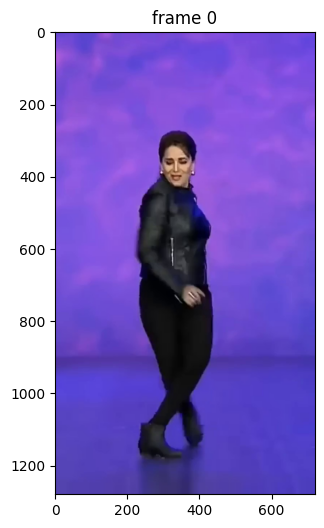

In [ ]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "frames_out"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [ ]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 200/200 [00:09<00:00, 20.47it/s]


/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


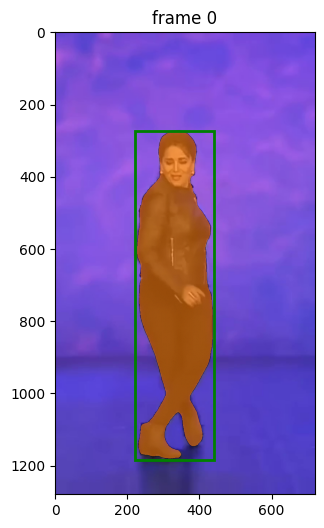

In [ ]:
# Initialize SAM2 prompts using YOLO + BoT-SORT outputs
ann_frame_idx = 0  # starting frame

# get objects from frame 0
frame_data = all_frames_data[ann_frame_idx]

for obj in frame_data:
    track_id = obj["track_id"]
    bbox = obj["bbox"]

    box = np.array(bbox, dtype=np.float32)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=track_id,   # use track_id directly
        box=box,
    )

# visualize
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))

for obj in frame_data:
    show_box(obj["bbox"], plt.gca())
    show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [ ]:
video_segments = {}
seen_track_ids = set()

# Create generator ONCE
prop_gen = predictor.propagate_in_video(inference_state)

for frame_idx in range(len(frame_names)):

    frame_data = all_frames_data[frame_idx]

    # Add prompts for NEW track_ids
    for obj in frame_data:
        track_id = obj["track_id"]

        if track_id not in seen_track_ids:
            bbox = obj["bbox"]
            box = np.array(bbox, dtype=np.float32)

            predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=frame_idx,
                obj_id=track_id,
                box=box,
            )

            seen_track_ids.add(track_id)

    # advance generator
    out_frame_idx, out_obj_ids, out_mask_logits = next(prop_gen)

    video_segments[out_frame_idx] = {}

    for i, out_obj_id in enumerate(out_obj_ids):
        mask = (out_mask_logits[i] > 0.0).cpu().numpy()
        video_segments[out_frame_idx][out_obj_id] = mask

    # attach mask
    for obj in frame_data:
        track_id = obj["track_id"]

        if track_id in video_segments[out_frame_idx]:
            obj["mask"] = video_segments[out_frame_idx][track_id]
        else:
            obj["mask"] = None

propagate in video: 100%|█████████▉| 199/200 [03:47<00:01,  1.17s/it]

DINO v2 Embeddings

In [ ]:
# =========================================
# DINOv2 Embeddings using SAM2 masks
# =========================================

import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import cv2
import os

# ----------------------------
# Device
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Load DINOv2
# ----------------------------
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2 = dinov2.to(device).eval()

for p in dinov2.parameters():
    p.data = p.data.float()

# ----------------------------
# Transform
# ----------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

# ----------------------------
# Extract embeddings
# ----------------------------
def extract_embeddings(frame, frame_data, batch_size=8):

    crops = []
    meta = []

    for obj in frame_data:
        mask = obj.get("mask", None)
        track_id = obj["track_id"]

        if mask is None:
            continue

        # (1, H, W) → (H, W)
        if mask.ndim == 3:
            mask = mask[0]

        # convert bool → uint8
        mask = mask.astype(np.uint8)

        # apply mask
        masked = frame * mask[..., None]

        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            continue

        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

        # skip tiny crops
        if (x2 - x1) < 10 or (y2 - y1) < 10:
            continue

        crop = masked[y1:y2, x1:x2].astype("uint8")

        crop_pil = Image.fromarray(crop)
        tensor = transform(crop_pil)

        crops.append(tensor)
        meta.append(track_id)

    if len(crops) == 0:
        return []

    crops = torch.stack(crops).to(device).float()

    embeddings = []

    with torch.no_grad():
        for i in range(0, len(crops), batch_size):
            batch = crops[i:i+batch_size]

            emb = dinov2(batch)
            emb = emb.cpu().numpy()

            for j in range(len(emb)):
                embeddings.append({
                    "track_id": meta[i + j],
                    "embedding": emb[j]
                })

    return embeddings

# ----------------------------
# MAIN LOOP
# ----------------------------
video_dir = "frames_out"

frame_names = sorted(
    [f for f in os.listdir(video_dir) if f.endswith(".jpg")],
    key=lambda x: int(os.path.splitext(x)[0])
)

for frame_idx, frame_name in enumerate(frame_names):

    frame_path = os.path.join(video_dir, frame_name)
    frame = cv2.imread(frame_path)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame_data = all_frames_data[frame_idx]

    embeddings = extract_embeddings(frame, frame_data)

    # map track_id → embedding
    trackid_to_emb = {e["track_id"]: e["embedding"] for e in embeddings}

    # attach embedding back
    for obj in frame_data:
        track_id = obj["track_id"]

        if track_id in trackid_to_emb:
            obj["embedding"] = trackid_to_emb[track_id]
        else:
            obj["embedding"] = None

    print(f"Frame {frame_idx}: {len(embeddings)} embeddings")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Frame 0: 1 embeddings
Frame 1: 1 embeddings
Frame 2: 1 embeddings
Frame 3: 1 embeddings
Frame 4: 1 embeddings
Frame 5: 1 embeddings
Frame 6: 1 embeddings
Frame 7: 1 embeddings
Frame 8: 1 embeddings
Frame 9: 1 embeddings
Frame 10: 1 embeddings
Frame 11: 1 embeddings
Frame 12: 1 embeddings
Frame 13: 1 embeddings
Frame 14: 1 embeddings
Frame 15: 1 embeddings
Frame 16: 1 embeddings
Frame 17: 1 embeddings
Frame 18: 1 embeddings
Frame 19: 1 embeddings
Frame 20: 1 embeddings
Frame 21: 1 embeddings
Frame 22: 1 embeddings
Frame 23: 1 embeddings
Frame 24: 1 embeddings
Frame 25: 1 embeddings
Frame 26: 1 embeddings
Frame 27: 1 embeddings
Frame 28: 1 embeddings
Frame 29: 1 embeddings
Frame 30: 1 embeddings
Frame 31: 1 embeddings
Frame 32: 1 embeddings
Frame 33: 1 embeddings
Frame 34: 1 embeddings
Frame 35: 1 embeddings
Frame 36: 1 embeddings
Frame 37: 1 embeddings
Frame 38: 1 embeddings
Frame 39: 1 embeddings
Frame 40: 1 embeddings
Frame 41: 1 embeddings
Frame 42: 1 embeddings
Frame 43: 1 embedding

In [ ]:
all_frames_data

[[{'frame_id': 0,
   'track_id': 1,
   'object_id': 0,
   'class': 'person',
   'bbox': [221.38787841796875,
    273.4811096191406,
    441.28289794921875,
    1183.3572998046875],
   'probability': 0.9385659694671631,
   'mask': array([[[False, False, False, ..., False, False, False],
           [False, False, False, ..., False, False, False],
           [False, False, False, ..., False, False, False],
           ...,
           [False, False, False, ..., False, False, False],
           [False, False, False, ..., False, False, False],
           [False, False, False, ..., False, False, False]]]),
   'embedding': array([    -7.3993,    -0.19199,     -1.5902,     -3.9264,    -0.77348,     -2.1617,     -1.3289,     0.89536,     -1.0827,    -0.42829,       3.854,    -0.68623,       3.003,      1.2067,      4.3301,     -1.9697,    0.079694,     -1.4242,     -3.2395,    -0.88696,      1.6039,      1.0167,      1.5058,    -0.65912,
              0.92856,    -0.22409,     0.30121,    -0.9997

In [ ]:
# check if embeddings generates across frames are consistent - using cosine similarity
import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# pick same track_id across two frames
emb1 = all_frames_data[0][0]["embedding"]
emb2 = all_frames_data[15][0]["embedding"]

print(cosine_similarity(emb1, emb2))

0.84887666


SAVE OUTPUT : .pkl.gz

In [ ]:
# =========================================
# SAVE all_frames_data
# =========================================

import gzip
import pickle

with gzip.open("all_frames_data.pkl.gz", "wb") as f:
    pickle.dump(all_frames_data, f)